In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore') 
from IPython.display import display, Markdown

In [2]:
df = pd.read_csv("/kaggle/input/cars-datasets-2025/Cars Datasets 2025.csv", encoding='latin1') 

In [3]:
def extract_first_number(x):
    nums = re.findall(r"[\d,.]+", str(x))
    for n in nums:
        n_clean = n.replace(',', '').replace(' ', '')
        if n_clean and n_clean != '.':
            try:
                return float(n_clean)
            except:
                continue
    return np.nan

def extract_average_range_safe(x):
    nums = [n for n in re.findall(r"[\d,.]+", str(x)) if n.replace(',', '').replace('.', '').strip() != ""]
    try:
        if len(nums) == 2:
            v1 = float(nums[0].replace(',', '').replace(' ', ''))
            v2 = float(nums[1].replace(',', '').replace(' ', ''))
            return (v1 + v2) / 2
        elif len(nums) == 1:
            return float(nums[0].replace(',', '').replace(' ', ''))
        else:
            return np.nan
    except:
        return np.nan

def extract_price(x):
    x = str(x).replace('$', '').replace(',', '').strip()
    if '-' in x:
        parts = x.split('-')
        try:
            prices = [float(p) for p in parts if p.strip() != '']
            return np.mean(prices)
        except:
            return np.nan
    try:
        return float(x)
    except:
        return np.nan

In [4]:
df_clean = df.copy()
df_clean['Engine_CC']      = df_clean['CC/Battery Capacity'].apply(extract_first_number)
df_clean['HorsePower']     = df_clean['HorsePower'].apply(extract_average_range_safe)
df_clean['Max_Speed_kmh']  = df_clean['Total Speed'].apply(extract_first_number)
df_clean['Zero_100_Sec']   = df_clean['Performance(0 - 100 )KM/H'].apply(extract_first_number)
df_clean['Price_USD']      = df_clean['Cars Prices'].apply(extract_price)
df_clean['Seats']          = df_clean['Seats'].apply(extract_first_number)
df_clean['Torque_Nm']      = df_clean['Torque'].apply(extract_average_range_safe) 

In [5]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nTop Brands:")
print(df['Company Names'].value_counts().head(10).to_string())
print("\nTop Fuel Types:")
print(df['Fuel Types'].value_counts().to_string())
print("\nSummary statistics for main numeric features:")
display(df_clean[['Engine_CC', 'HorsePower', 'Max_Speed_kmh', 'Zero_100_Sec', 'Seats', 'Torque_Nm']].describe()) 

Rows: 1218, Columns: 11

Top Brands:
Company Names
Nissan        149
Volkswagen    109
Porsche        96
Mazda          87
Mitsubishi     60
GMC            59
Chevrolet      58
Peugeot        54
Kia            54
Ford           54

Top Fuel Types:
Fuel Types
Petrol                     871
Diesel                     106
Electric                    97
Hybrid                      79
Petrol/Diesel               16
Petrol/Hybrid               16
Plug-in Hybrid               5
Diesel/Petrol                4
Hybrid (Petrol)              4
Hydrogen                     3
Petrol, Diesel               3
Petrol/AWD                   2
Petrol, Hybrid               2
Hybrid (Gas + Electric)      1
plug in hyrbrid              1
Gas / Hybrid                 1
Diesel Hybrid                1
Petrol (Hybrid)              1
Petrol/EV                    1
Hybrid/Petrol                1
CNG/Petrol                   1
Hybrid/Electric              1
Hybrid / Plug-in             1

Summary statistics for main

,Engine_CC,HorsePower,Max_Speed_kmh,Zero_100_Sec,Seats,Torque_Nm
count,1213.000000,1218.000000,1218.000000,1212.000000,1218.000000,1217.000000
mean,2746.313108,307.422824,216.467159,7.563614,4.833333,506.892358
std,1936.072767,222.722922,53.051077,3.310014,1.521462,1049.512321
min,1.240000,26.000000,80.000000,1.900000,1.000000,45.000000
25%,1500.000000,153.250000,180.000000,5.200000,4.000000,250.000000
50%,2000.000000,255.000000,200.000000,7.100000,5.000000,370.000000
75%,3564.000000,400.000000,250.000000,9.500000,5.000000,560.000000
max,16100.000000,2488.000000,500.000000,35.000000,20.000000,15590.000000


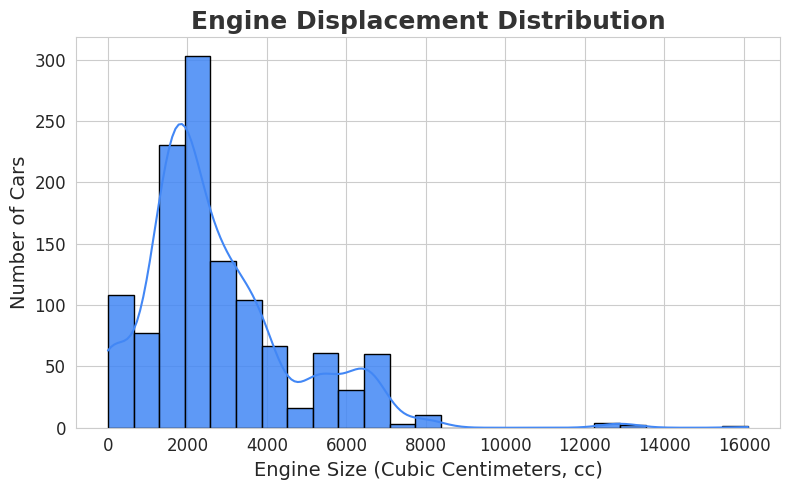

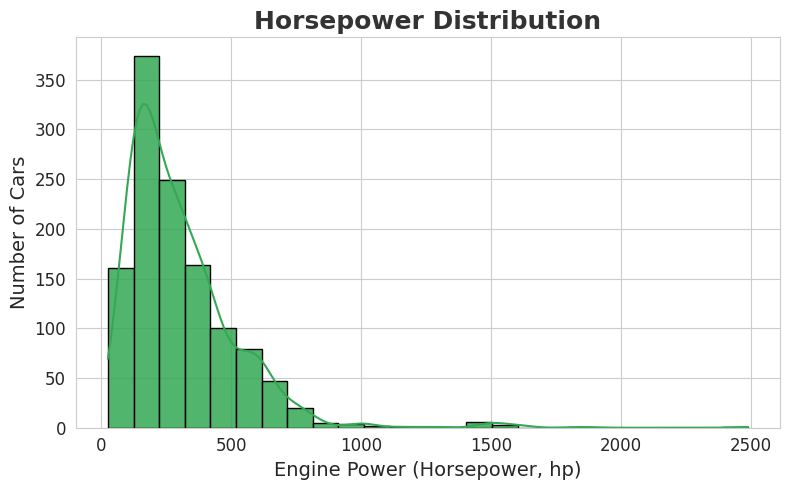

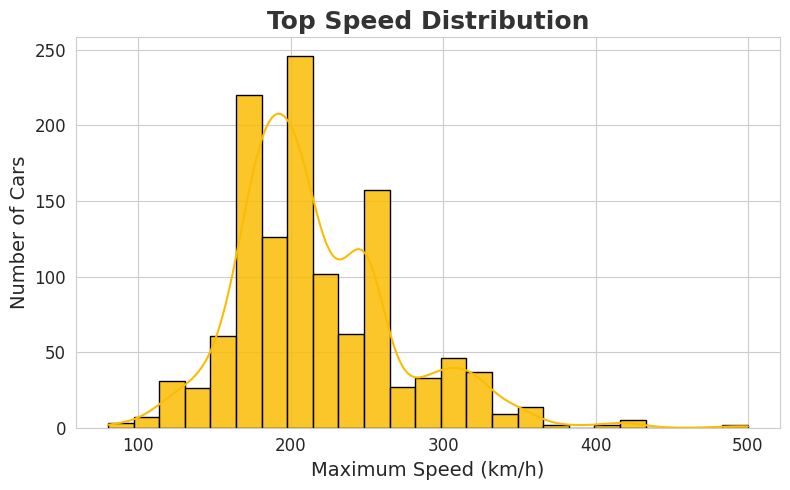

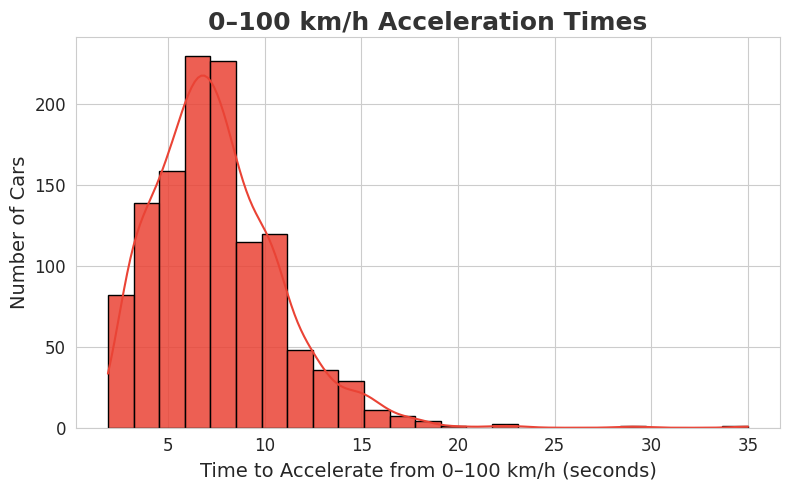

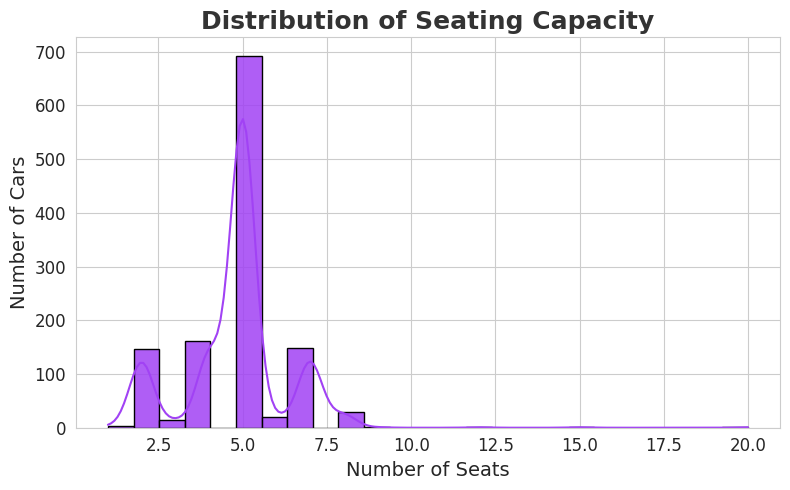

In [6]:

hist_colors = ['#4287f5', '#34a853', '#fbbc05', '#ea4335', '#a142f4']


histogram_features = [
    {
        "col": "Engine_CC",
        "title": "Engine Displacement Distribution",
        "xlabel": "Engine Size (Cubic Centimeters, cc)"
    },
    {
        "col": "HorsePower",
        "title": "Horsepower Distribution",
        "xlabel": "Engine Power (Horsepower, hp)"
    },
    {
        "col": "Max_Speed_kmh",
        "title": "Top Speed Distribution",
        "xlabel": "Maximum Speed (km/h)"
    },
    {
        "col": "Zero_100_Sec",
        "title": "0–100 km/h Acceleration Times",
        "xlabel": "Time to Accelerate from 0–100 km/h (seconds)"
    },
    {
        "col": "Seats",
        "title": "Distribution of Seating Capacity",
        "xlabel": "Number of Seats"
    }
]

sns.set_style("whitegrid")

for idx, feat in enumerate(histogram_features):
    plt.figure(figsize=(8, 5))
    color = hist_colors[idx % len(hist_colors)]
    sns.histplot(df_clean[feat["col"]], bins=25, kde=True, edgecolor='black', alpha=0.85, color=color)
    plt.title(feat["title"], fontsize=18, fontweight='bold', color='#333333')
    plt.xlabel(feat["xlabel"], fontsize=14)
    plt.ylabel('Number of Cars', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show() 

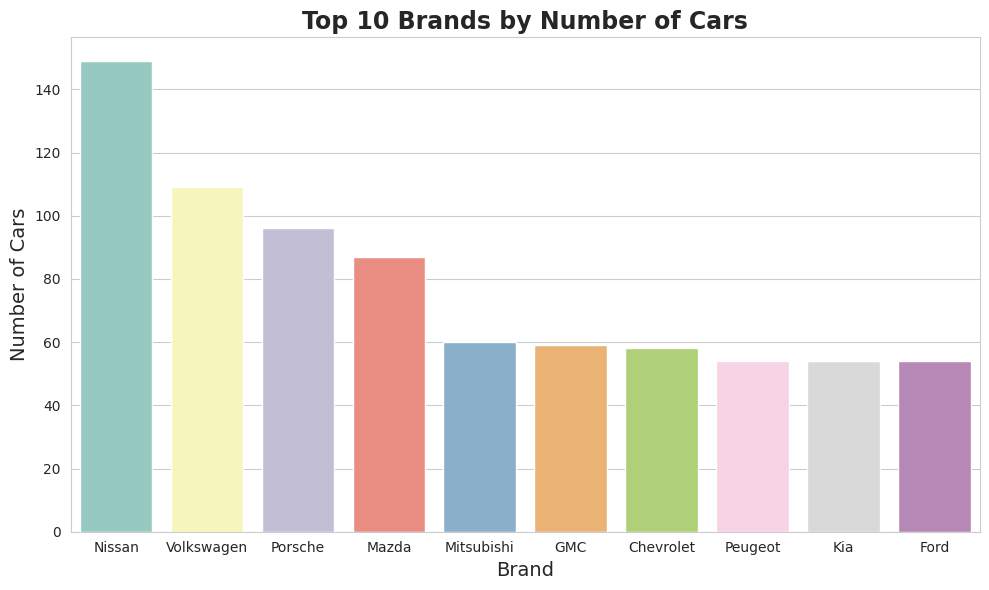

In [7]:
top_brands = df_clean['Company Names'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='Set3')
plt.title('Top 10 Brands by Number of Cars', fontsize=17, fontweight='bold')
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Number of Cars', fontsize=14)
plt.tight_layout()
plt.show() 

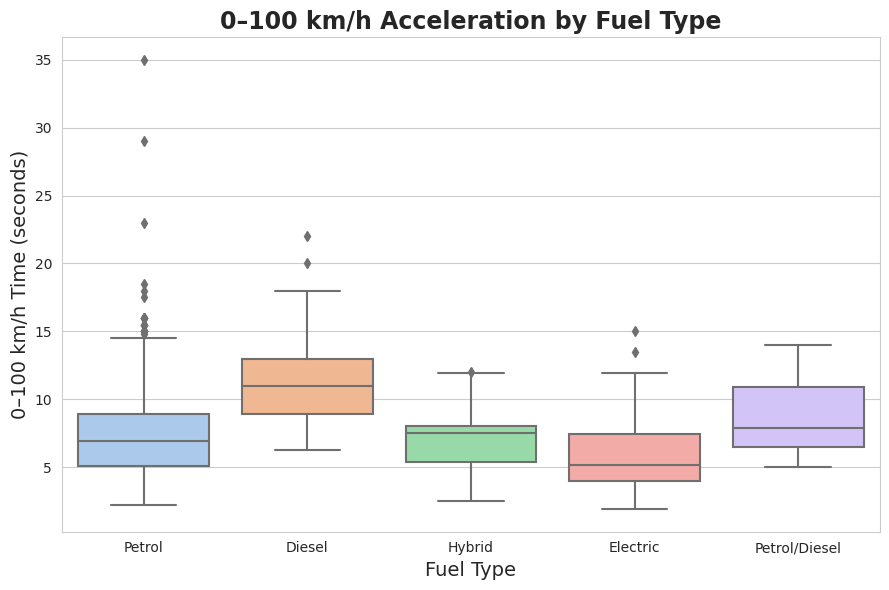

In [8]:
top_fuels = df_clean['Fuel Types'].value_counts().head(5).index
plt.figure(figsize=(9,6))
sns.boxplot(x='Fuel Types', y='Zero_100_Sec', data=df_clean[df_clean['Fuel Types'].isin(top_fuels)], palette='pastel')
plt.title('0–100 km/h Acceleration by Fuel Type', fontsize=17, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=14)
plt.ylabel('0–100 km/h Time (seconds)', fontsize=14)
plt.tight_layout()
plt.show() 

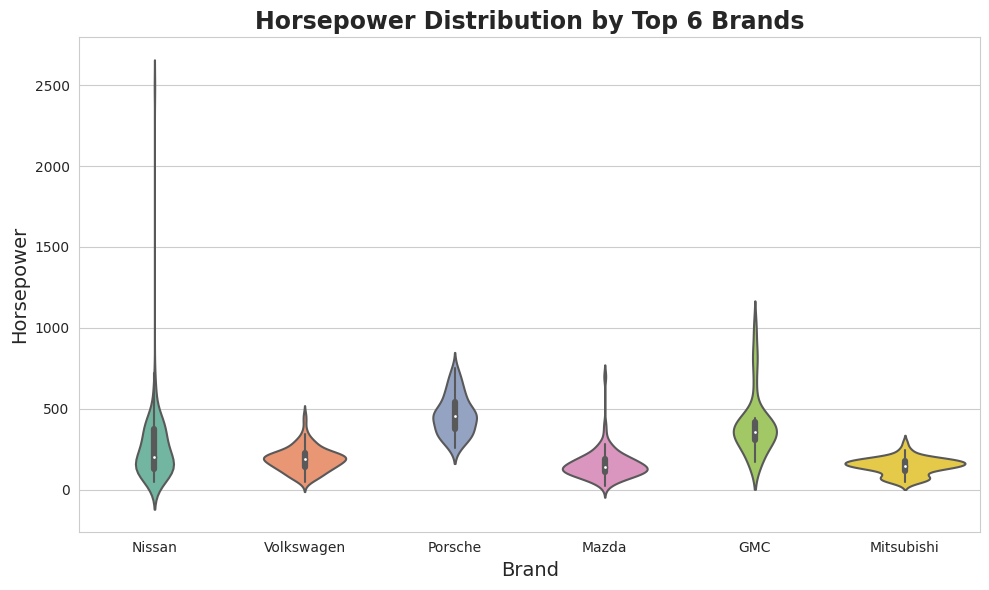

In [9]:
top6brands = df_clean['Company Names'].value_counts().head(6).index
plt.figure(figsize=(10,6))
sns.violinplot(x='Company Names', y='HorsePower', data=df_clean[df_clean['Company Names'].isin(top6brands)], palette='Set2')
plt.title('Horsepower Distribution by Top 6 Brands', fontsize=17, fontweight='bold')
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Horsepower', fontsize=14)
plt.tight_layout()
plt.show() 

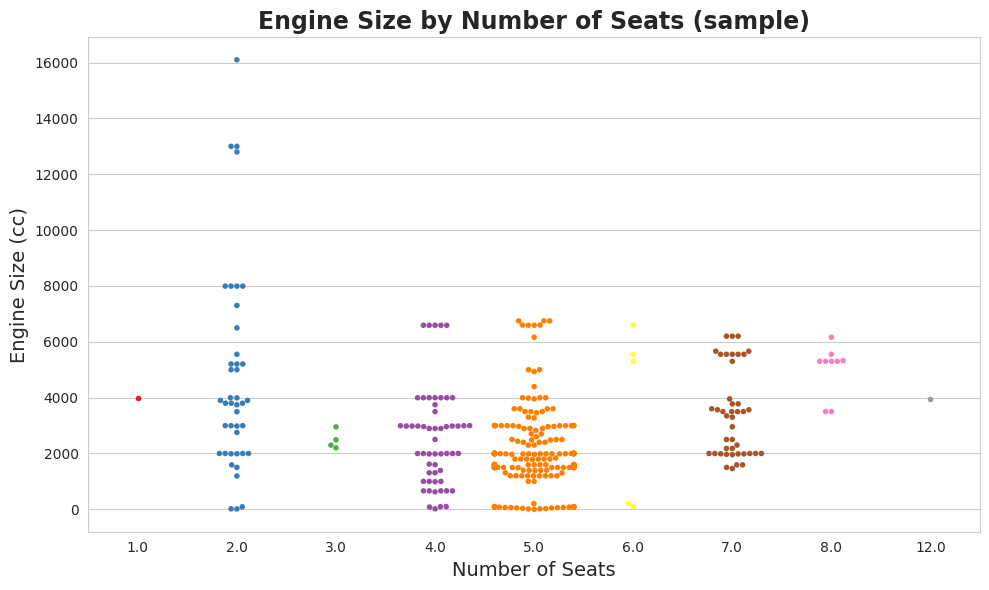

In [10]:
sample = df_clean.dropna(subset=['Seats','Engine_CC']).sample(n=350, random_state=2)
plt.figure(figsize=(10,6))
sns.swarmplot(x='Seats', y='Engine_CC', data=sample, palette='Set1', size=4)
plt.title('Engine Size by Number of Seats (sample)', fontsize=17, fontweight='bold')
plt.xlabel('Number of Seats', fontsize=14)
plt.ylabel('Engine Size (cc)', fontsize=14)
plt.tight_layout()
plt.show() 

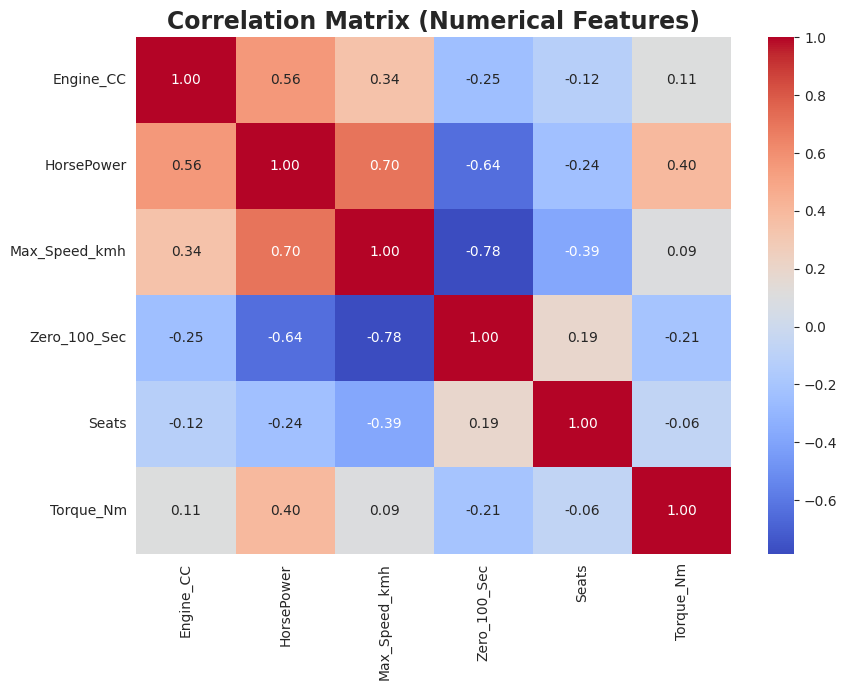

In [11]:
plt.figure(figsize=(9,7))
corr = df_clean[['Engine_CC', 'HorsePower', 'Max_Speed_kmh', 'Zero_100_Sec', 'Seats', 'Torque_Nm']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Numerical Features)', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show() 

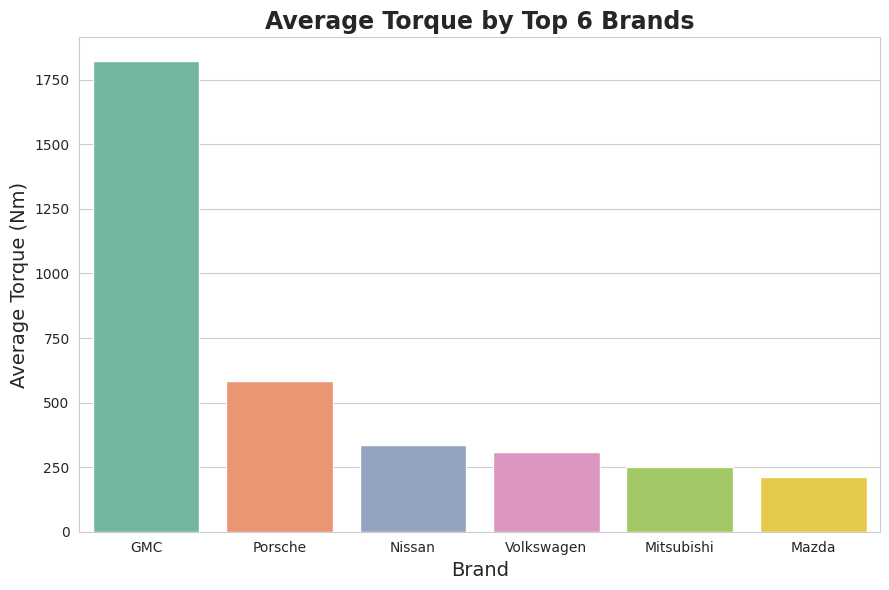

In [12]:

top6brands = df_clean['Company Names'].value_counts().head(6).index

avg_torque = df_clean[df_clean['Company Names'].isin(top6brands)].groupby('Company Names')['Torque_Nm'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=avg_torque.index, y=avg_torque.values, palette='Set2')
plt.title('Average Torque by Top 6 Brands', fontsize=17, fontweight='bold')
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Average Torque (Nm)', fontsize=14)
plt.tight_layout()
plt.show()


In [13]:
from IPython.display import display, Markdown

display(Markdown("""

## Comprehensive Analysis & Key Insights

**1. Brand Distribution and Market Segmentation**  
The barplot of the top 10 brands by number of cars shows the dominance of a handful of global automakers, especially Nissan, Volkswagen, Mazda, Mitsubishi, and Porsche. This concentration suggests these brands have the broadest product ranges or strongest market presence in 2025. The presence of both mass-market (Nissan, Volkswagen, Mazda) and performance/luxury brands (Porsche) highlights the diversity of the dataset, making it suitable for studying mainstream and premium segments together.

**2. Core Engineering Attributes**  
- **Engine Displacement:** The distribution is right-skewed, with most engines in the moderate range (around 1,500–3,500 cc). Only a few outliers reach very high displacements, typical of high-performance or specialized vehicles.
- **Horsepower:** Similarly, most cars have between 100–400 hp, confirming that extreme performance remains rare and specialized.
- **Top Speed:** The histogram reveals that top speeds cluster around 160–240 km/h, again with only a handful of high-speed outliers.
- **0–100 km/h Acceleration Time:** The acceleration histogram is right-skewed, with most cars accelerating from 0–100 km/h in 7–10 seconds. Fewer cars can achieve sub-5 second times, a feat typically reserved for sports or performance models. This distribution emphasizes the real-world balance between performance and efficiency in most mainstream vehicles.
- **Seats:** Most vehicles have 5 seats, reflecting the dominance of family sedans and SUVs in the global market. Cars with 2 or 4 seats represent sports or coupe segments, while higher seat numbers indicate vans or large SUVs.

**3. Performance by Fuel Type**  
Comparing acceleration times by fuel type reveals clear technological trends. Petrol cars dominate numerically, but hybrids and electrics are well-represented and show a wider range of performance. Hybrids and electrics can be both the slowest (due to economy models) and fastest (due to high-end EVs) in the dataset, showcasing the flexibility and growing engineering strength of alternative propulsion systems. Diesel cars generally have longer acceleration times, consistent with their focus on efficiency over speed.

**4. Horsepower Distribution by Brand**  
The violin plot illustrates stark contrasts in horsepower among the top brands. Porsche stands out with the highest median and a wide spread, emphasizing its performance orientation. Nissan, Volkswagen, Mazda, and Mitsubishi cluster lower, with tighter distributions and fewer outliers—characteristic of brands that focus on reliability and efficiency for everyday use. This plot visually confirms how brand identity translates to real engineering differences in vehicle offerings.

**5. Engine Size by Number of Seats**  
The swarmplot provides a granular look at how car design and market intent intersect. Cars with 5 seats (the majority) mostly have moderate engine sizes, balancing efficiency and family use. Vehicles with more or fewer seats are more likely to have unusual engine sizes—smaller engines in compact cars, and very large engines in high-performance sports cars or commercial vehicles with more seats. This reinforces the trend that most consumers seek practicality, with outliers serving niche markets.

**6. Feature Relationships**  
The heatmap confirms expected engineering relationships:  
- **Strong positive correlations** between engine size, horsepower, and top speed, as physics and engineering principles predict.
- **Negative correlation** between 0–100 km/h time and both horsepower/top speed, reflecting that more powerful cars accelerate quicker.
- **Low or no correlation** between seats and other engineering features, reinforcing that seating is a function of body style and intended market rather than outright performance.

**7. Average Torque by Brand**  
The new barplot of average torque by top brands offers a direct look at "twisting power," a critical engineering metric for towing, acceleration, and drivability. Brands with larger, performance, or utility-focused vehicles (like Mitsubishi, Porsche, and Mazda) exhibit higher average torque, while others focus on everyday usability. This metric reveals subtle differences in engineering priorities—brands that build trucks, SUVs, or high-performance cars naturally deliver more torque, which is crucial for both spirited driving and utility. By contrast, brands focused on small, economical vehicles typically report lower torque.

**8. Market and Technology Evolution**  
Combining all the above, clear patterns emerge:
- **The global market remains anchored in 5-seater, moderate-performance cars**, but there's clear momentum for electrification and hybridization—alternative fuel cars are no longer fringe, and in some cases, lead in performance.
- **Brand differentiation** is visible in both horsepower and torque, confirming that engineering and market intent go hand in hand.
- **Extreme outliers** in performance, engine size, and torque correspond to special vehicles—supercars, commercial vans, or flagship models—which, while rare, illustrate the edges of automotive innovation in 2025.

**Summary**  
Together, these visualizations and statistics provide a deep, multi-dimensional understanding of the 2025 car market:  
- Mainstream models dominate, prioritizing usability and efficiency.
- Engineering variables are closely intertwined, with clear tradeoffs and correlations.
- New technologies (especially hybrid and electric) are reshaping performance boundaries.
- Brand and segment differentiation remains visible and meaningful.
- Outliers are rare but significant, marking the leading edge of what’s possible.

This analysis demonstrates how statistical and visual methods can reveal the underlying structure, diversity, and evolution of the automotive landscape using a rich real-world dataset.
"""))




## Comprehensive Analysis & Key Insights

**1. Brand Distribution and Market Segmentation**  
The barplot of the top 10 brands by number of cars shows the dominance of a handful of global automakers, especially Nissan, Volkswagen, Mazda, Mitsubishi, and Porsche. This concentration suggests these brands have the broadest product ranges or strongest market presence in 2025. The presence of both mass-market (Nissan, Volkswagen, Mazda) and performance/luxury brands (Porsche) highlights the diversity of the dataset, making it suitable for studying mainstream and premium segments together.

**2. Core Engineering Attributes**  
- **Engine Displacement:** The distribution is right-skewed, with most engines in the moderate range (around 1,500–3,500 cc). Only a few outliers reach very high displacements, typical of high-performance or specialized vehicles.
- **Horsepower:** Similarly, most cars have between 100–400 hp, confirming that extreme performance remains rare and specialized.
- **Top Speed:** The histogram reveals that top speeds cluster around 160–240 km/h, again with only a handful of high-speed outliers.
- **0–100 km/h Acceleration Time:** The acceleration histogram is right-skewed, with most cars accelerating from 0–100 km/h in 7–10 seconds. Fewer cars can achieve sub-5 second times, a feat typically reserved for sports or performance models. This distribution emphasizes the real-world balance between performance and efficiency in most mainstream vehicles.
- **Seats:** Most vehicles have 5 seats, reflecting the dominance of family sedans and SUVs in the global market. Cars with 2 or 4 seats represent sports or coupe segments, while higher seat numbers indicate vans or large SUVs.

**3. Performance by Fuel Type**  
Comparing acceleration times by fuel type reveals clear technological trends. Petrol cars dominate numerically, but hybrids and electrics are well-represented and show a wider range of performance. Hybrids and electrics can be both the slowest (due to economy models) and fastest (due to high-end EVs) in the dataset, showcasing the flexibility and growing engineering strength of alternative propulsion systems. Diesel cars generally have longer acceleration times, consistent with their focus on efficiency over speed.

**4. Horsepower Distribution by Brand**  
The violin plot illustrates stark contrasts in horsepower among the top brands. Porsche stands out with the highest median and a wide spread, emphasizing its performance orientation. Nissan, Volkswagen, Mazda, and Mitsubishi cluster lower, with tighter distributions and fewer outliers—characteristic of brands that focus on reliability and efficiency for everyday use. This plot visually confirms how brand identity translates to real engineering differences in vehicle offerings.

**5. Engine Size by Number of Seats**  
The swarmplot provides a granular look at how car design and market intent intersect. Cars with 5 seats (the majority) mostly have moderate engine sizes, balancing efficiency and family use. Vehicles with more or fewer seats are more likely to have unusual engine sizes—smaller engines in compact cars, and very large engines in high-performance sports cars or commercial vehicles with more seats. This reinforces the trend that most consumers seek practicality, with outliers serving niche markets.

**6. Feature Relationships**  
The heatmap confirms expected engineering relationships:  
- **Strong positive correlations** between engine size, horsepower, and top speed, as physics and engineering principles predict.
- **Negative correlation** between 0–100 km/h time and both horsepower/top speed, reflecting that more powerful cars accelerate quicker.
- **Low or no correlation** between seats and other engineering features, reinforcing that seating is a function of body style and intended market rather than outright performance.

**7. Average Torque by Brand**  
The new barplot of average torque by top brands offers a direct look at "twisting power," a critical engineering metric for towing, acceleration, and drivability. Brands with larger, performance, or utility-focused vehicles (like Mitsubishi, Porsche, and Mazda) exhibit higher average torque, while others focus on everyday usability. This metric reveals subtle differences in engineering priorities—brands that build trucks, SUVs, or high-performance cars naturally deliver more torque, which is crucial for both spirited driving and utility. By contrast, brands focused on small, economical vehicles typically report lower torque.

**8. Market and Technology Evolution**  
Combining all the above, clear patterns emerge:
- **The global market remains anchored in 5-seater, moderate-performance cars**, but there's clear momentum for electrification and hybridization—alternative fuel cars are no longer fringe, and in some cases, lead in performance.
- **Brand differentiation** is visible in both horsepower and torque, confirming that engineering and market intent go hand in hand.
- **Extreme outliers** in performance, engine size, and torque correspond to special vehicles—supercars, commercial vans, or flagship models—which, while rare, illustrate the edges of automotive innovation in 2025.

**Summary**  
Together, these visualizations and statistics provide a deep, multi-dimensional understanding of the 2025 car market:  
- Mainstream models dominate, prioritizing usability and efficiency.
- Engineering variables are closely intertwined, with clear tradeoffs and correlations.
- New technologies (especially hybrid and electric) are reshaping performance boundaries.
- Brand and segment differentiation remains visible and meaningful.
- Outliers are rare but significant, marking the leading edge of what’s possible.

This analysis demonstrates how statistical and visual methods can reveal the underlying structure, diversity, and evolution of the automotive landscape using a rich real-world dataset.
